In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [3]:
mle_model = LogisticRegression(
    penalty=None,
    max_iter=1000
)

mle_model.fit(X_train, y_train)

y_pred_mle = mle_model.predict(X_test)


In [4]:
l2_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000
)

l2_model.fit(X_train, y_train)

y_pred_l2 = l2_model.predict(X_test)


In [5]:

l1_model = LogisticRegression(
    penalty='l1',
    C=1.0,
    solver='liblinear',
    max_iter=1000
)

l1_model.fit(X_train, y_train)

y_pred_l1 = l1_model.predict(X_test)

In [6]:
def evaluate_model(name, y_true, y_pred):

    print("\n", "="*40)
    print(name)
    print("="*40)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

In [7]:
evaluate_model("MLE Logistic Regression", y_test, y_pred_mle)

evaluate_model("MAP Logistic Regression (L2)", y_test, y_pred_l2)

evaluate_model("MAP Logistic Regression (L1)", y_test, y_pred_l1)



MLE Logistic Regression
Accuracy : 0.9385964912280702
Precision: 0.9848484848484849
Recall   : 0.9154929577464789
F1 Score : 0.948905109489051

MAP Logistic Regression (L2)
Accuracy : 0.9736842105263158
Precision: 0.9722222222222222
Recall   : 0.9859154929577465
F1 Score : 0.979020979020979

MAP Logistic Regression (L1)
Accuracy : 0.9736842105263158
Precision: 0.9857142857142858
Recall   : 0.971830985915493
F1 Score : 0.9787234042553192


In [10]:
coef_table = pd.DataFrame({ 
    "Feature": data.feature_names, 
    "MLE": mle_model.coef_[0],
    "L2": l2_model.coef_[0],
    "L1": l1_model.coef_[0] })

print("\nFirst 10 Coefficients\n") 
print(coef_table.head(8))


First 10 Coefficients

               Feature         MLE        L2        L1
0          mean radius   18.674433 -0.427896  0.000000
1         mean texture  -38.770421 -0.393913  0.000000
2       mean perimeter   85.863999 -0.389550  0.000000
3            mean area   21.825723 -0.464316  0.000000
4      mean smoothness    9.945701 -0.066754  0.000000
5     mean compactness  599.625747  0.542106  0.000000
6       mean concavity -292.316154 -0.796771  0.000000
7  mean concave points -579.850455 -1.117021 -2.438432


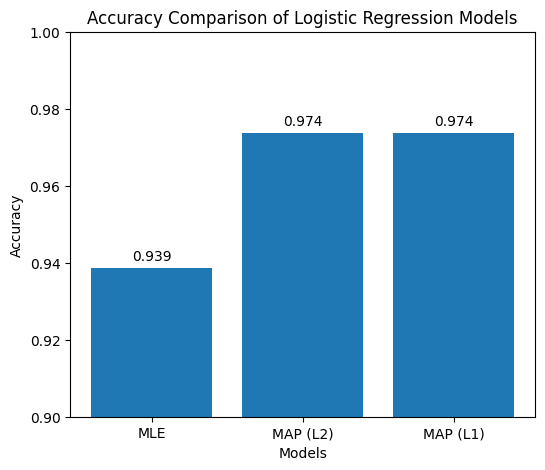

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Calculate accuracies
acc_mle = accuracy_score(y_test, y_pred_mle)
acc_l2 = accuracy_score(y_test, y_pred_l2)
acc_l1 = accuracy_score(y_test, y_pred_l1)

# Model names
models = ['MLE', 'MAP (L2)', 'MAP (L1)']
accuracies = [acc_mle, acc_l2, acc_l1]

# Plot
plt.figure(figsize=(6,5))
plt.bar(models, accuracies)

plt.title("Accuracy Comparison of Logistic Regression Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.00)

# Show accuracy values on bars
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.002, f"{acc:.3f}", ha='center')

plt.show()

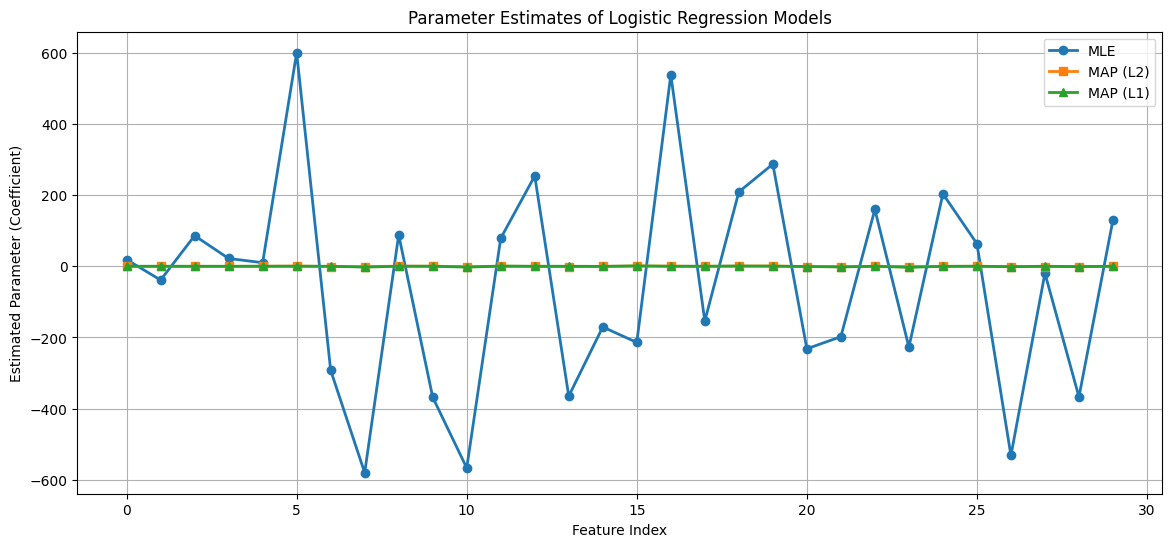

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Estimated parameters (coefficients)
mle_params = mle_model.coef_[0]
l2_params = l2_model.coef_[0]
l1_params = l1_model.coef_[0]

# Feature indices
features = np.arange(len(mle_params))

# Create the graph
plt.figure(figsize=(14,6))

plt.plot(features, mle_params, marker='o', label='MLE', linewidth=2)
plt.plot(features, l2_params, marker='s', label='MAP (L2)', linewidth=2)
plt.plot(features, l1_params, marker='^', label='MAP (L1)', linewidth=2)

# Labels and title
plt.title("Parameter Estimates of Logistic Regression Models")
plt.xlabel("Feature Index")
plt.ylabel("Estimated Parameter (Coefficient)")
plt.legend()
plt.grid(True)

plt.show()